In [5]:
# Imports
import tkinter as tk
from tkinter import filedialog, messagebox, font
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk

In [6]:
# --- Constants ---
# Densities in kg/m^3
FLUID_DENSITIES = {
    "Water": 1000,
    "Ethanol": 789,
    "LOX (Liquid Oxygen)": 1141,
    "IPA (Isopropyl Alcohol)": 786,
    "LN2 (Liquid Nitrogen)": 808,
}

# --- Global Variables ---
df = None  # Holds the loaded DataFrame
time_col_sec = "Time (s)" # Name of the new seconds column

# --- Plotting-specific globals ---
plot_window = None
plot_canvas = None
plot_fig = None
plot_ax1 = None
plot_ax2 = None
plot_markers = [] # List to store markers (lines and text)

In [7]:
def calculate_cda():
    """
    Calculates the average CdA based on user inputs for time splice,
    fluid density, and ambient pressure. Handles unit conversions and
    mass flow rate calculation from weight if necessary.
    """
    if df is None:
        messagebox.showwarning("No Data", "Please load and plot data first.")
        return

    # --- 1. Get Inputs ---
    try:
        start_time = float(start_time_entry.get())
        end_time = float(end_time_entry.get())
        p_ambient = float(p_ambient_entry.get())
    except ValueError:
        messagebox.showerror("Input Error", "Start Time, End Time, and Ambient Pressure must be numbers.")
        return

    fluid_name = fluid_var.get()
    density = FLUID_DENSITIES.get(fluid_name)
    pressure_col = pressure_var.get()
    mdot_col = mdot_var.get()
    mdot_unit = mdot_unit_var.get()

    # --- 2. Validate Inputs ---
    if start_time >= end_time:
        messagebox.showerror("Input Error", "Start Time must be less than End Time.")
        return
        
    if not density:
        messagebox.showerror("Input Error", "Please select a valid fluid.")
        return

    # --- 3. Splice Data ---
    spliced_df = df[
        (df[time_col_sec] >= start_time) & (df[time_col_sec] <= end_time)
    ].copy() # Use .copy() to avoid SettingWithCopyWarning

    if spliced_df.empty:
        messagebox.showwarning("No Data", "No data found in the specified time range.")
        return

    # --- 4. Calculate CdA ---
    # Equation: mdot = CdA * sqrt(2 * rho * delta_p)
    # Rearranged: CdA = mdot / sqrt(2 * rho * delta_p)
    
    try:
        # --- 1. Calculate Average Pressure & Delta P ---
        avg_pressure = spliced_df[pressure_col].mean()
        
        # Convert avg_pressure from PSI to Pa
        avg_pressure_pa = avg_pressure * 6894.76
        
        # Check if input is Gauge or Absolute
        if gauge_var.get():
            # If Gauge, Delta P is just the pressure (assuming ambient is reference 0 for the gauge)
            delta_p = avg_pressure_pa
        else:
            # If Absolute, Delta P = P_upstream_abs - P_ambient_abs
            delta_p = avg_pressure_pa - p_ambient
        
        if delta_p <= 0:
            messagebox.showwarning("Calculation Error", 
                                   f"Average pressure in range ({avg_pressure:.2f} PSI / {avg_pressure_pa:.2f} Pa) "
                                   f"is not greater than ambient pressure ({p_ambient} Pa).")
            return

        # --- 2. Calculate Mass Flow Rate (Mdot) ---
        # Units: kg/s, lb/s, kg, lbs
        
        # Conversion factors
        LB_TO_KG = 0.453592
        
        if mdot_unit in ["kg", "lbs"]:
            # Cumulative Mass/Weight -> Calculate Slope (Derivative)
            # We use linear regression (polyfit degree 1) to get the slope over the range
            
            # Get time and mass/weight arrays
            t_data = spliced_df[time_col_sec].values
            m_data = spliced_df[mdot_col].values
            
            if len(t_data) < 2:
                 messagebox.showwarning("Calculation Error", "Not enough data points to calculate slope.")
                 return

            # Calculate slope (units/sec)
            slope, intercept = np.polyfit(t_data, m_data, 1)
            
            # Mass flow rate is the absolute value of the slope (assuming mass decreases)
            raw_mdot = abs(slope)
            
            # Convert to kg/s if necessary
            if mdot_unit == "lbs":
                mdot_kg_s = raw_mdot * LB_TO_KG
            else: # kg
                mdot_kg_s = raw_mdot
                
        else: # "kg/s" or "lb/s"
            # Rate -> Calculate Mean
            raw_mdot = spliced_df[mdot_col].mean()
            raw_mdot = abs(raw_mdot) # Ensure positive
            
            # Convert to kg/s if necessary
            if mdot_unit == "lb/s":
                mdot_kg_s = raw_mdot * LB_TO_KG
            else: # kg/s
                mdot_kg_s = raw_mdot
        
        if mdot_kg_s == 0:
            messagebox.showwarning("Calculation Error", "Calculated Mass Flow Rate is 0.")
            return

        # --- 3. Calculate Final CdA ---
        # CdA = mdot / sqrt(2 * rho * delta_p)
        denominator = np.sqrt(2 * density * delta_p)
        
        if denominator == 0:
            messagebox.showwarning("Calculation Error", "Calculation denominator is zero (check density or delta_p).")
            return
            
        avg_cda = mdot_kg_s / denominator
        
        # Display the result
        result_label.config(text=f"{avg_cda:.5e} m^2")
        
    except Exception as e:
        messagebox.showerror("Calculation Error", f"An error occurred during calculation: {e}")

In [ ]:
# --- GUI Setup ---
gui = tk.Tk()
gui.title("CdA Calculator")
gui.geometry("1000x800")

# Set a slightly larger default font
default_font = font.nametofont("TkDefaultFont")
default_font.configure(size=11)

# --- Top Frame (File & Column Selection) ---
top_frame = tk.Frame(gui, bd=2, relief=tk.RIDGE, padx=5, pady=5)
top_frame.pack(side=tk.TOP, fill=tk.X, pady=5, padx=5)

# Row 0: File Loading
load_button = tk.Button(top_frame, text="Load CSV File", command=load_csv)
load_button.grid(row=0, column=0, padx=5, pady=5, sticky="w")
file_label = tk.Label(top_frame, text="No file loaded", relief=tk.SUNKEN, anchor="w", width=40)
file_label.grid(row=0, column=1, columnspan=2, padx=5, sticky="ew")

# Row 1: Column Labels
tk.Label(top_frame, text="Time Column:").grid(row=1, column=0, padx=5, sticky="e")
tk.Label(top_frame, text="Pressure Column:").grid(row=1, column=1, padx=5, sticky="e")
tk.Label(top_frame, text="Mdot Column:").grid(row=1, column=2, padx=5, sticky="e")

# Row 2: Column Dropdowns
time_var = tk.StringVar(gui)
time_menu = tk.OptionMenu(top_frame, time_var, " (Load CSV first) ")
time_menu.grid(row=2, column=0, padx=5, sticky="ew")

pressure_var = tk.StringVar(gui)
pressure_menu = tk.OptionMenu(top_frame, pressure_var, " (Load CSV first) ")
pressure_menu.grid(row=2, column=1, padx=5, sticky="ew")

mdot_var = tk.StringVar(gui)
mdot_menu = tk.OptionMenu(top_frame, mdot_var, " (Load CSV first) ")
mdot_menu.grid(row=2, column=2, padx=5, sticky="ew")

# Row 2.5: Mdot/Weight Unit Selection
tk.Label(top_frame, text="Mdot/Weight Unit:").grid(row=1, column=3, padx=5, sticky="e")
mdot_unit_var = tk.StringVar(gui)
mdot_unit_var.set("kg/s") # Default
mdot_unit_menu = tk.OptionMenu(top_frame, mdot_unit_var, "kg/s", "lb/s", "kg", "lbs")
mdot_unit_menu.grid(row=2, column=3, padx=5, sticky="ew")

# Update column configure to handle 4th column
top_frame.grid_columnconfigure(3, weight=1)

# Row 3: Plot Button
plot_button = tk.Button(top_frame, text="Confirm Columns & Plot Data", command=plot_data, state=tk.DISABLED, bg="#D4EDDA")
plot_button.grid(row=3, column=0, columnspan=4, pady=10, padx=5, sticky="ew")

# Configure grid expansion
top_frame.grid_columnconfigure(0, weight=1)
top_frame.grid_columnconfigure(1, weight=1)
top_frame.grid_columnconfigure(2, weight=1)

# --- Bottom Frame (Splicing & Calculation) ---
bottom_frame = tk.Frame(gui, bd=2, relief=tk.RIDGE, padx=5, pady=5)
bottom_frame.pack(side=tk.BOTTOM, fill=tk.X, pady=5, padx=5)

# Row 0: Splicing Inputs
tk.Label(bottom_frame, text="Start Time (s):").grid(row=0, column=0, padx=5, pady=5, sticky="e")
start_time_entry = tk.Entry(bottom_frame, width=10)
start_time_entry.grid(row=0, column=1, padx=5, pady=5)

tk.Label(bottom_frame, text="End Time (s):").grid(row=0, column=2, padx=5, pady=5, sticky="e")
end_time_entry = tk.Entry(bottom_frame, width=10)
end_time_entry.grid(row=0, column=3, padx=5, pady=5)

# Row 1: Calculation Inputs
tk.Label(bottom_frame, text="Fluid:").grid(row=1, column=0, padx=5, pady=5, sticky="e")
fluid_var = tk.StringVar(gui)
fluid_var.set("Select Fluid")
fluid_menu = tk.OptionMenu(bottom_frame, fluid_var, *FLUID_DENSITIES.keys())
fluid_menu.grid(row=1, column=1, padx=5, pady=5, sticky="ew")

tk.Label(bottom_frame, text="Ambient Pressure (Pa):").grid(row=1, column=2, padx=5, pady=5, sticky="e")
p_ambient_entry = tk.Entry(bottom_frame, width=10)
p_ambient_entry.insert(0, "101325") # Default to 1 atm
p_ambient_entry.grid(row=1, column=3, padx=5, pady=5)

# Row 2: Gauge Pressure Checkbox
gauge_var = tk.BooleanVar(value=True) # Default to True (Gauge)
gauge_check = tk.Checkbutton(bottom_frame, text="Input is Gauge Pressure", variable=gauge_var)
gauge_check.grid(row=2, column=0, columnspan=2, padx=5, pady=5, sticky="w")

# Row 3: Calculation Button
calc_button = tk.Button(bottom_frame, text="Calculate Average CdA", command=calculate_cda, state=tk.DISABLED, bg="#D1ECF1")
calc_button.grid(row=3, column=0, columnspan=2, pady=10, padx=5, sticky="ew")

clear_marker_button = tk.Button(bottom_frame, text="Clear Plot Markers", command=clear_markers, bg="#F8D7DA")
clear_marker_button.grid(row=3, column=2, columnspan=2, pady=10, padx=5, sticky="ew")

# Row 4: Result Display
result_title_label = tk.Label(bottom_frame, text="Average CdA (m^2):")
result_title_label.grid(row=4, column=0, columnspan=2, padx=5, pady=5, sticky="e")

result_label = tk.Label(bottom_frame, text="N/A", font=("TkDefaultFont", 12, "bold"), relief=tk.SUNKEN, width=20)
result_label.grid(row=4, column=2, columnspan=2, padx=5, pady=5, sticky="w")

# Configure grid expansion
bottom_frame.grid_columnconfigure(1, weight=1)
bottom_frame.grid_columnconfigure(3, weight=1)

NameError: name 'load_csv' is not defined

: 

/var/folders/0j/jrk4ghtd6wqfsm3km6pbbyn80000gn/T/ipykernel_14898/1846401826.py:127: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  time_datetime = pd.to_datetime(df[time_col], infer_datetime_format=True)


KeyboardInterrupt: 

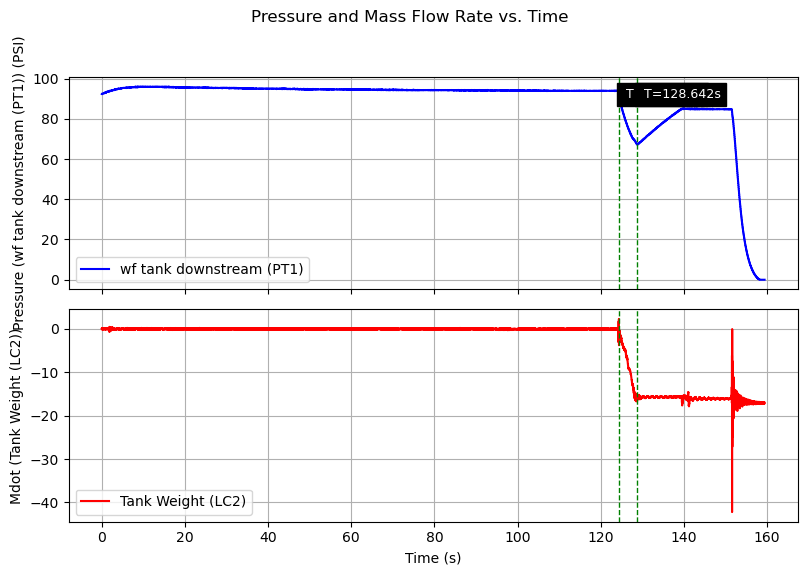

In [ ]:
gui.mainloop()